# Rectangular Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
from core.em_project import EMProject

project_name = 'RWG_step'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

Project 'RWG_step' exists. Loading automatically...
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  : ['port1 (external, input)', 'port2 (external, output)']
Restored PortEigenmodeSolver with 2 ports, 6 total modes
FrequencyDomainSolver state loaded from C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\RWG_step\fds
INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  : ['port1 (external, input)', 'port2 (external, output)']


## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [3]:
# import step file
geo = proj.import_geometry(r"./rectangular_waveguide.step", auto_build=False) # auto_build false so as not
                                                                      # to build the geo and mesh until after
                                                                      # defining ports
geo.build()
geo.name_faces_by_position(axis='Z')
geo.generate_mesh(maxh=0.04)
geo.show()

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': 3…

## 3. Full-Order Numerical Solution

Run a full-order finite element frequency sweep.

In [4]:
fom_config = {
    'nportmodes': 3,
    'nsamples': 100,
    'fmin': 1e-3,
    'fmax': 3,
    'solver_type': 'iterative'
}
fom_result = proj.fds.solve(config=fom_config)

C:\Users\Soske\AppData\Local\Temp\ipykernel_26380\2021823961.py:8: UserWarning: Results already exist for this solver. To overwrite, call solve(..., rerun=True).
  fom_result = proj.fds.solve(config=fom_config)


In [5]:
proj.fds.port_solver.port_orientation_factors

{'port1': 1.0, 'port2': -1.0}

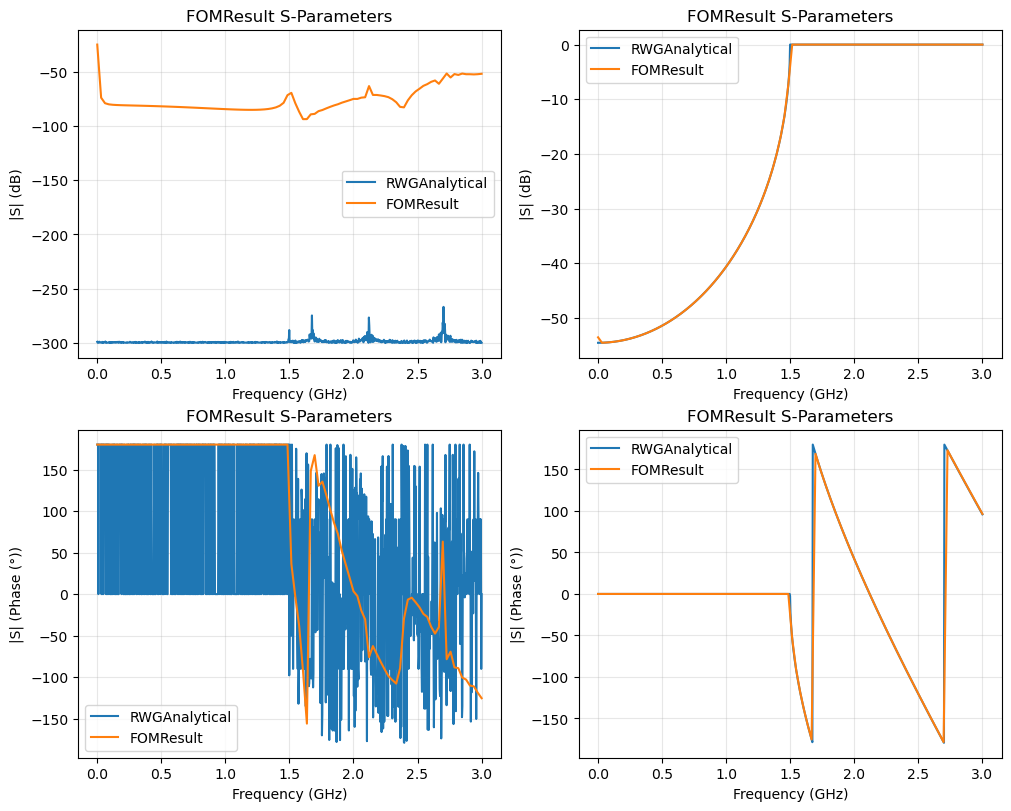

In [6]:
# Get analytic solution for comparison
from analytical.rectangular_waveguide import RWGAnalytical

a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
analytical = RWGAnalytical(a=a, L=L, freq_range=(fom_config['fmin'], fom_config['fmax']))

# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1])
    proj.fds.fom.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx+3])

In [7]:
proj.fds.plot_port_mode('port2', mode=0, component='abs')


Port Mode: port2 [external (output)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [8]:
# Plot with clipping plane
proj.fds.plot_field(freq_idx=25, component='abs', clipping={'x': 0, 'y': 0, 'z': 1})


Field visualization at f = 0.7583 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (abs)


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'camera': {'euler_angles': [4…

In [9]:
# Reduce model order
rom = proj.fds.fom.reduce()
rom_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 3,
    'solver_type': 'direct' # <- changed to direct method, faster for smaller matrices
}
rom_result = rom.solve(config=rom_config) # solve reduced order model on more frequency samples


Model Order Reduction
INFO:: 
Domain: 
Total: 2548 → 111 DOFs
Overall compression: 95.6%
  Solve loop: 0.038s (1000 freq points)


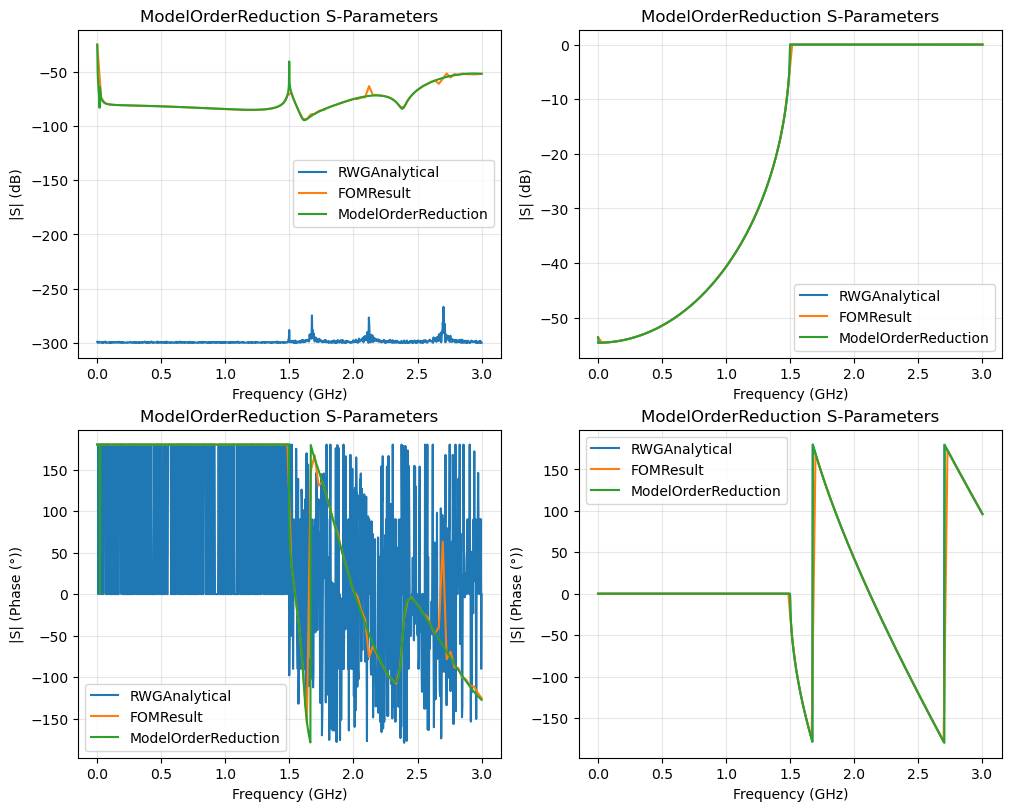

In [10]:
# compare fom, rom and analytical solution
# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1])
    proj.fds.fom.plot_s(wh, ax=axs[idx+1])
    rom.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.fom.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    rom.plot_s(wh, plot_type='phase', ax=axs[idx+3])